In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/workspaces/practice_models/House Price model/house_price_train.csv')
print('Shape:', df.shape)
print('\nTarget colum stats:')
print(df['SalePrice'].describe())

Shape: (1460, 81)

Target colum stats:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

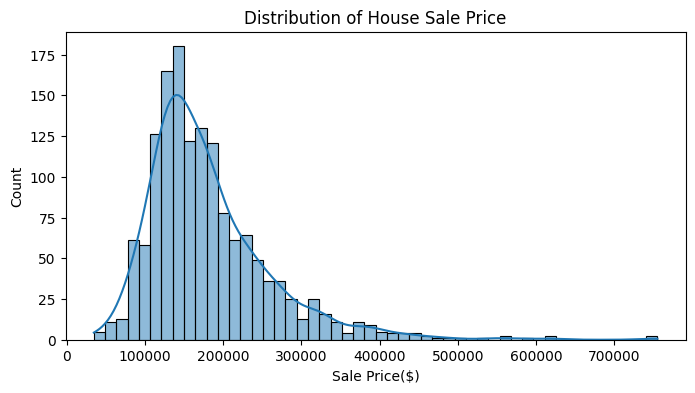

In [4]:
plt.figure(figsize=(8,4))
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title('Distribution of House Sale Price')
plt.xlabel('Sale Price($)')
plt.show()

In [5]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
print(df['TotalSF'])

0       2566
1       2524
2       2706
3       2473
4       3343
        ... 
1455    2600
1456    3615
1457    3492
1458    2156
1459    2512
Name: TotalSF, Length: 1460, dtype: int64


In [6]:
df['TotalBaths'] = (df['FullBath'] +
                    df['HalfBath'] * 0.5 +
                    df['BsmtFullBath'] +
                    df['BsmtHalfBath'] * 0.5)
print(df['TotalBaths'].head(10))

0    3.5
1    2.5
2    3.5
3    2.0
4    3.5
5    2.5
6    3.0
7    3.5
8    2.0
9    2.0
Name: TotalBaths, dtype: float64


In [7]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
print(df['HouseAge'].head(50))

0      5
1     31
2      7
3     91
4      8
5     16
6      3
7     36
8     77
9     69
10    43
11     1
12    46
13     1
14    48
15    78
16    40
17    39
18     4
19    51
20     1
21    77
22     6
23    31
24    42
25     2
26    59
27     3
28    49
29    81
30    88
31    42
32     1
33    51
34     2
35     2
36    15
37    55
38    57
39    53
40    41
41    48
42    24
43    33
44    47
45     5
46     6
47     1
48    89
49    41
Name: HouseAge, dtype: int64


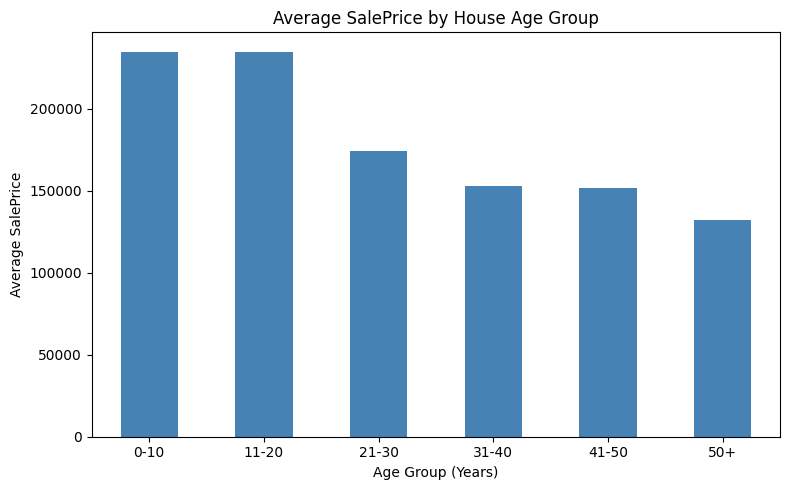

In [8]:
df['AgeGroup'] = pd.cut(df['HouseAge'], bins=[0, 10, 20, 30, 40, 50, 100],
                         labels=['0-10', '11-20', '21-30', '31-40', '41-50', '50+'])
df.groupby('AgeGroup')['SalePrice'].mean().plot(kind='bar', color='steelblue', figsize=(8, 5))
plt.title('Average SalePrice by House Age Group')
plt.xlabel('Age Group (Years)')
plt.ylabel('Average SalePrice')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
df['WasRemodelled'] = (df['YearRemodAdd'] !=df['YearBuilt']).astype(int)
print('WasRemodelled')

WasRemodelled


In [10]:
print('New features added!')
print(df[['TotalSF', 'TotalBaths', 'HouseAge', 'WasRemodelled']].head())


New features added!
   TotalSF  TotalBaths  HouseAge  WasRemodelled
0     2566         3.5         5              0
1     2524         2.5        31              0
2     2706         3.5         7              1
3     2473         2.0        91              1
4     3343         3.5         8              0


In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('SalePrice')
num_cols.remove('Id')

X = df[num_cols]
Y = df['SalePrice']

X.fillna(X.median())

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f'Features used: {len(num_cols)}')
print(f'Training rows: {len(X_train)}')

Features used: 40
Training rows: 1168


In [12]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
Y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)
print('=' * 40)
print('   HOUSE PRICE MODEL REPORT')
print('=' * 40)
print(f'R2 Score:  {r2:.4f}')
print(f'RMSE:      ${rmse:,.0f}')


   HOUSE PRICE MODEL REPORT
R2 Score:  0.8844
RMSE:      $29,779


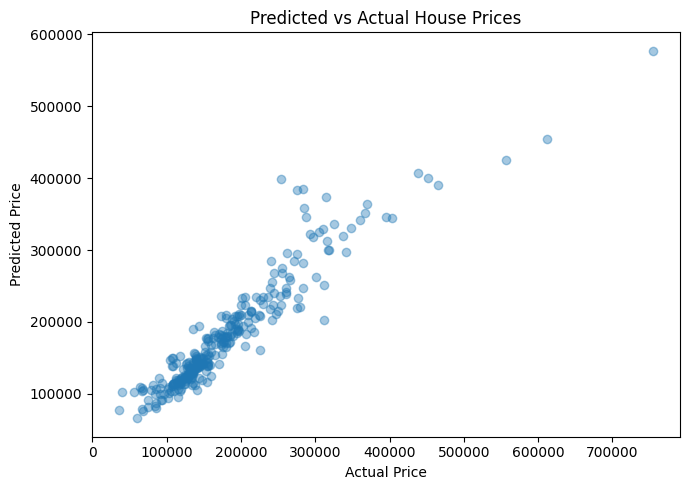

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(Y_test, Y_pred, alpha=0.4)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual House Prices')
plt.tight_layout()
plt.show()

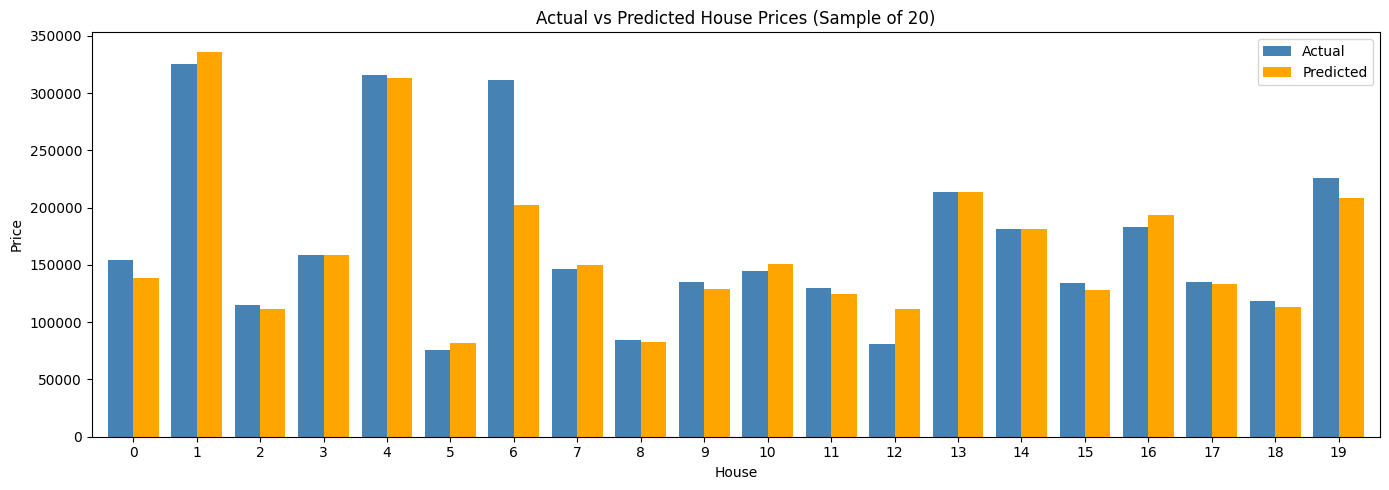

In [15]:
sample = pd.DataFrame({'Actual': Y_test[:20].values,
                        'Predicted': Y_pred[:20]})

sample.plot(kind='bar', figsize=(14, 5),
            color=['steelblue', 'orange'],
            width=0.8)

plt.title('Actual vs Predicted House Prices (Sample of 20)')
plt.xlabel('House')
plt.ylabel('Price')
plt.xticks(rotation=0)
plt.legend(['Actual', 'Predicted'])
plt.tight_layout()
plt.show()